# Install & Imports

In [4]:
import sys

!{sys.executable} -m pip install -q \
ultralytics \
opencv-python-headless \
seaborn \
tqdm \
pycocotools

In [105]:
import os
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random

# DATA INGESTION

In [106]:
DATASET_ROOT = "UVH-26" # DATASET ROOT

TRAIN_DIR = os.path.join(DATASET_ROOT, "UVH-26-Train")
VAL_DIR   = os.path.join(DATASET_ROOT, "UVH-26-Val")

print("TRAIN DIR:", TRAIN_DIR)
print("VAL DIR  :", VAL_DIR)

TRAIN DIR: UVH-26/UVH-26-Train
VAL DIR  : UVH-26/UVH-26-Val


# ANNOTATION PARSING & VALIDATION

In [107]:
train_jsons = [
    f for f in os.listdir(TRAIN_DIR)
    if f.endswith(".json")
]

print("Train JSON Files:")
print(train_jsons)

train_json_paths = [
    os.path.join(TRAIN_DIR, f)
    for f in train_jsons
]
# MERGE COCO JSONS
def merge_coco_jsons(json_paths):

    merged = {
        "images": [],
        "annotations": [],
        "categories": None
    }

    image_ids = set()
    ann_ids = set()

    for path in json_paths:

        print("\nLoading:", os.path.basename(path))

        with open(path, "r") as f:

            coco = json.load(f)


        if merged["categories"] is None:

            merged["categories"] = coco["categories"]


        for img in coco["images"]:

            if img["id"] not in image_ids:

                merged["images"].append(img)

                image_ids.add(img["id"])


        for ann in coco["annotations"]:

            if ann["id"] not in ann_ids:

                merged["annotations"].append(ann)

                ann_ids.add(ann["id"])

    return merged


train_coco = merge_coco_jsons(
    train_json_paths
)

print("\n====================================")
print("TRAIN COCO MERGED SUCCESSFULLY")
print("====================================")

print("Images      :", len(train_coco['images']))
print("Annotations :", len(train_coco['annotations']))
print("Classes     :", len(train_coco['categories']))

print("\nClass Names:")

for i, cat in enumerate(train_coco['categories']):

    print(f"{i}: {cat['name']}")

Train JSON Files:
['UVH-26-ST-Train.json', 'UVH-26-MV-Train.json']

Loading: UVH-26-ST-Train.json

Loading: UVH-26-MV-Train.json

TRAIN COCO MERGED SUCCESSFULLY
Images      : 21349
Annotations : 298191
Classes     : 14

Class Names:
0: Hatchback
1: Sedan
2: SUV
3: MUV
4: Bus
5: Truck
6: Three-wheeler
7: Two-wheeler
8: LCV
9: Mini-bus
10: Tempo-traveller
11: Bicycle
12: Van
13: Others


# Validate Annotation Consistency

In [108]:
missing_images = annotations[~annotations['image_id'].isin(images['id'])]
print("Invalid annotations:", len(missing_images))

Invalid annotations: 0


# EDA & DATA QUALITY CHECKS

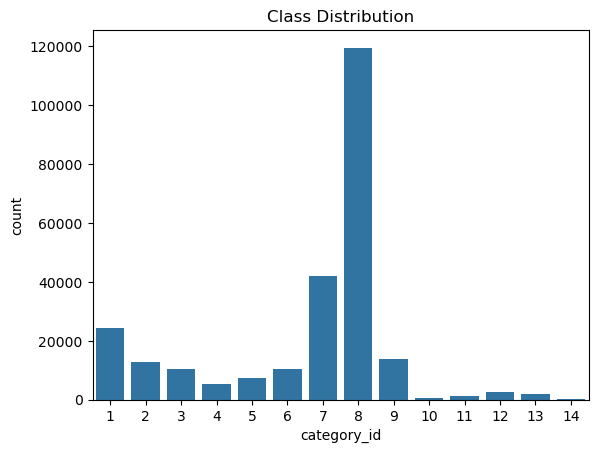

In [109]:
sns.countplot(x='category_id', data=annotations)
plt.title("Class Distribution")
plt.show()

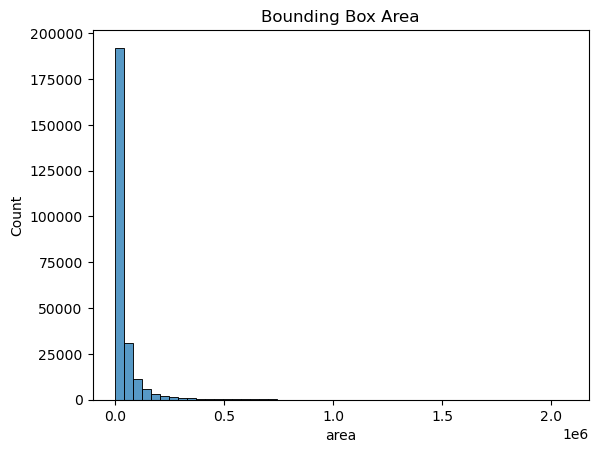

In [110]:
annotations['area'] = annotations['bbox'].apply(lambda x: x[2]*x[3])

sns.histplot(annotations['area'], bins=50)
plt.title("Bounding Box Area")
plt.show()

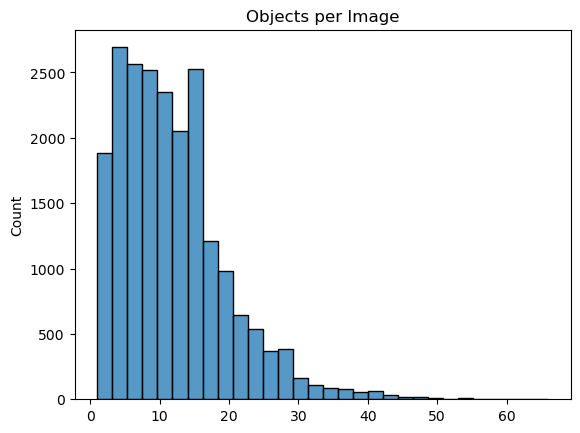

In [111]:
obj_per_img = annotations.groupby('image_id').size()

sns.histplot(obj_per_img, bins=30)
plt.title("Objects per Image")
plt.show()

# Sample Visualization

Selected File: 565405.png
Using Image: UVH-26/UVH-26-Train/data/002/565405.png
Annotations Found: 39


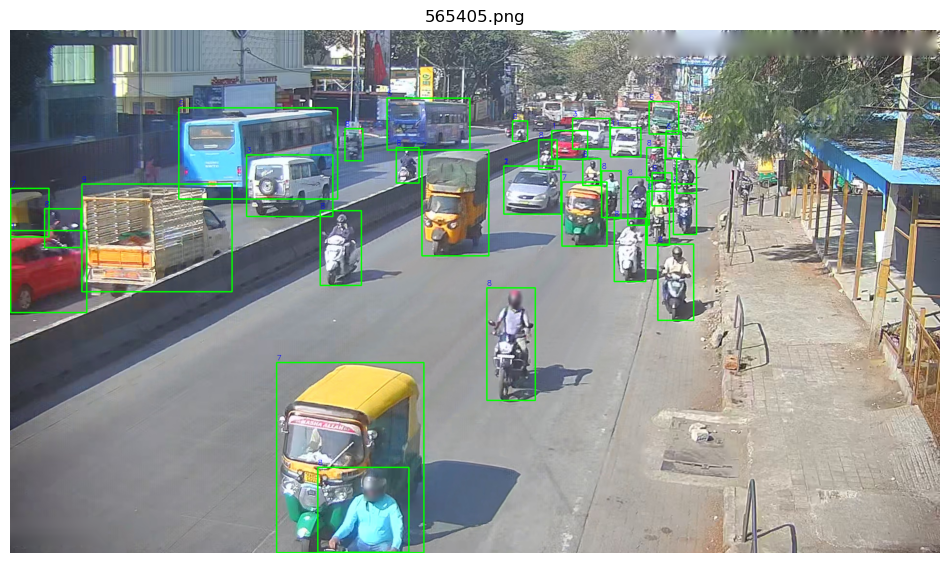

In [115]:
# IMAGE FINDER
def find_image(root_dir, filename):

    base = os.path.splitext(filename)[0]

    for subdir, _, files in os.walk(root_dir):

        for f in files:

            # match filename without extension
            if os.path.splitext(f)[0] == base:
                return os.path.join(subdir, f)

    return None
# IMAGE ROOT
IMG_DIR = TRAIN_DIR 
# RANDOM IMAGE
sample_img = random.choice(train_coco['images'])

file_name = sample_img['file_name']

print("Selected File:", file_name)
# FIND IMAGE
img_path = find_image(IMG_DIR, file_name)

if img_path is None:
    raise FileNotFoundError(f"Image not found: {file_name}")

print("Using Image:", img_path)
# LOAD IMAGE
img = cv2.imread(img_path)

if img is None:
    raise ValueError(f"OpenCV failed to read image: {img_path}")
# GET ANNOTATIONS
img_id = str(sample_img['id'])

anns = [
    ann for ann in train_coco['annotations']
    if str(ann['image_id']) == img_id
]

print("Annotations Found:", len(anns))
# DRAW BOUNDING BOXES
for ann in anns:

    x, y, w, h = map(int, ann['bbox'])

    cv2.rectangle(
        img,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    # show category id
    cv2.putText(
        img,
        str(ann['category_id']),
        (x, y - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.title(file_name)
plt.axis("off")
plt.show()

# Quality Checks

• Corrupt images
• Blur detection
• Brightness analysis


In [116]:
from concurrent.futures import ThreadPoolExecutor
# CONFIG
BLUR_THRESHOLD = 20      
DARK_THRESHOLD = 40        
BRIGHT_THRESHOLD = 220    
MAX_WORKERS = 8         

IMG_ROOT = "UVH-26/UVH-26-Train/data"
# FIND ALL IMAGES INCLUDING SUBFOLDERS
def get_all_images(root):
    img_paths = []
    for subdir, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                img_paths.append(os.path.join(subdir, f))
    return img_paths

image_paths = get_all_images(IMG_ROOT)
print("Total images found:", len(image_paths))
# QUALITY CHECK FUNCTION
def analyze_image(path):
    result = {
        "path": path,
        "corrupt": False,
        "blur": False,
        "dark": False,
        "bright": False
    }

    try:
        img = cv2.imread(path)

        # Corrupt check
        if img is None:
            result["corrupt"] = True
            return result

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Blur detection
        blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
        if blur_score < BLUR_THRESHOLD:
            result["blur"] = True

        # Brightness
        brightness = np.mean(gray)

        if brightness < DARK_THRESHOLD:
            result["dark"] = True
        elif brightness > BRIGHT_THRESHOLD:
            result["bright"] = True

    except Exception:
        result["corrupt"] = True

    return result
# MULTI-THREAD EXECUTION
results = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    for res in tqdm(executor.map(analyze_image, image_paths), total=len(image_paths)):
        results.append(res)

corrupt = [r for r in results if r["corrupt"]]
blur = [r for r in results if r["blur"]]
dark = [r for r in results if r["dark"]]
bright = [r for r in results if r["bright"]]

print("\n===== QUALITY REPORT =====")
print("Corrupt images:", len(corrupt))
print("Blur images:", len(blur))
print("Dark images:", len(dark))
print("Bright images:", len(bright))

# SAVE BAD FILE LIST
bad_images = set()

for group in [corrupt, blur, dark, bright]:
    for r in group:
        bad_images.add(r["path"])

bad_images = list(bad_images)

print("Total problematic images:", len(bad_images))
# SAVE BAD IMAGE LIST
SAVE_DIR = os.path.join(os.getcwd(), "quality_check")

os.makedirs(SAVE_DIR, exist_ok=True)

BAD_IMAGE_PATH = os.path.join(
    SAVE_DIR,
    "bad_images.npy"
)

np.save(BAD_IMAGE_PATH, bad_images)

print("\nBad image list saved:")
print(BAD_IMAGE_PATH)

Total images found: 21351


100%|██████████| 21351/21351 [06:01<00:00, 59.13it/s]


===== QUALITY REPORT =====
Corrupt images: 0
Blur images: 31
Dark images: 0
Bright images: 0
Total problematic images: 31

Bad image list saved:
/home/jovyan/work/quality_check/bad_images.npy


# DATASET CONVERSION (COCO → YOLO)

In [117]:
# BAD IMAGE LIST
BAD_IMAGE_PATH = os.path.join(
    os.getcwd(),
    "quality_check",
    "bad_images.npy"
)

if os.path.exists(BAD_IMAGE_PATH):

    bad_images = set([
        os.path.basename(x)
        for x in np.load(
            BAD_IMAGE_PATH,
            allow_pickle=True
        )
    ])

    print("Bad images loaded:", len(bad_images))

else:

    bad_images = set()

    print("No bad image file found")

# OUTPUT DIRECTORY
YOLO_DIR = os.path.join(
    os.getcwd(),
    "yolo_dataset"
)

TRAIN_IMG_OUT = os.path.join(
    YOLO_DIR,
    "images",
    "train"
)

VAL_IMG_OUT = os.path.join(
    YOLO_DIR,
    "images",
    "val"
)

TRAIN_LBL_OUT = os.path.join(
    YOLO_DIR,
    "labels",
    "train"
)

VAL_LBL_OUT = os.path.join(
    YOLO_DIR,
    "labels",
    "val"
)

# CREATE DIRECTORIES
os.makedirs(TRAIN_IMG_OUT, exist_ok=True)
os.makedirs(VAL_IMG_OUT, exist_ok=True)

os.makedirs(TRAIN_LBL_OUT, exist_ok=True)
os.makedirs(VAL_LBL_OUT, exist_ok=True)

# FIND IMAGE INSIDE SUBFOLDERS
def find_image(root_dir, filename):

    base = os.path.splitext(filename)[0]

    for subdir, _, files in os.walk(root_dir):

        for f in files:

            if os.path.splitext(f)[0] == base:

                return os.path.join(subdir, f)

    return None

# COCO → YOLO CONVERSION
def convert_coco_to_yolo(
    coco_json,
    image_root,
    image_out,
    label_out,
    split_name="train"
):

    print(f"\n========== {split_name.upper()} ==========")

    # CATEGORY MAP

    cat_map = {
        cat['id']: i
        for i, cat in enumerate(coco_json['categories'])
    }

    names = [
        cat['name']
        for cat in coco_json['categories']
    ]

    # GROUP ANNOTATIONS

    ann_dict = {}

    for ann in coco_json['annotations']:

        ann_dict.setdefault(
            str(ann['image_id']),
            []
        ).append(ann)

    # COUNTERS

    missing = 0
    empty = 0
    valid = 0
    skipped_bad = 0

    # PROCESS IMAGES

    for img in tqdm(coco_json['images']):

        file_name = img['file_name']

        img_id = str(img['id'])

        img_path = find_image(
            image_root,
            file_name
        )

        # MISSING IMAGE

        if img_path is None:

            missing += 1

            continue

        # BAD IMAGE FILTER

        if file_name in bad_images:

            skipped_bad += 1

            continue

        # GET ANNOTATIONS

        anns = ann_dict.get(img_id, [])

        # EMPTY LABELS

        if len(anns) == 0:

            empty += 1

            continue

        # COPY IMAGE

        shutil.copy(
            img_path,
            os.path.join(
                image_out,
                file_name
            )
        )

        h = img['height']
        w = img['width']

        base_name = os.path.splitext(file_name)[0]

        label_path = os.path.join(
            label_out,
            base_name + ".txt"
        )

        # WRITE LABELS

        with open(label_path, "w") as f:

            for ann in anns:

                x, y, bw, bh = ann['bbox']

                x_center = (x + bw / 2) / w
                y_center = (y + bh / 2) / h

                bw = bw / w
                bh = bh / h

                # INVALID BOXES

                if bw <= 0 or bh <= 0:

                    continue

                if not (
                    0 <= x_center <= 1 and
                    0 <= y_center <= 1
                ):

                    continue

                cls = cat_map[ann['category_id']]

                f.write(
                    f"{cls} "
                    f"{x_center:.6f} "
                    f"{y_center:.6f} "
                    f"{bw:.6f} "
                    f"{bh:.6f}\n"
                )

        valid += 1

    print(f"\n{split_name.upper()} SUMMARY")

    print("Valid Images     :", valid)
    print("Missing Images   :", missing)
    print("Empty Labels     :", empty)
    print("Skipped Bad Img  :", skipped_bad)
    print("Labels Created   :", len(os.listdir(label_out)))
    print("Images Copied    :", len(os.listdir(image_out)))

    return names

print("\n====================================")
print("USING PRELOADED MERGED COCO DATA")
print("====================================")

print("\nTRAIN")
print("Images      :", len(train_coco['images']))
print("Annotations :", len(train_coco['annotations']))

print("\nVAL")
print("Images      :", len(val_coco['images']))
print("Annotations :", len(val_coco['annotations']))

# CONVERT TRAIN
train_names = convert_coco_to_yolo(
    coco_json=train_coco,
    image_root=TRAIN_DIR,
    image_out=TRAIN_IMG_OUT,
    label_out=TRAIN_LBL_OUT,
    split_name="train"
)

# CONVERT VAL
convert_coco_to_yolo(
    coco_json=val_coco,
    image_root=VAL_DIR,
    image_out=VAL_IMG_OUT,
    label_out=VAL_LBL_OUT,
    split_name="val"
)

# CREATE data.yaml
yaml_path = os.path.join(
    YOLO_DIR,
    "data.yaml"
)

with open(yaml_path, "w") as f:

    f.write(f"""
path: {YOLO_DIR}

train: images/train
val: images/val

nc: {len(train_names)}

names: {train_names}
""")

print("\n====================================")
print("YOLO DATASET CREATED SUCCESSFULLY")
print("====================================")

print("YOLO DIR  :", YOLO_DIR)
print("data.yaml :", yaml_path)

Bad images loaded: 31

USING PRELOADED MERGED COCO DATA

TRAIN
Images      : 21349
Annotations : 298191

VAL
Images      : 5297
Annotations : 109241

========== TRAIN ==========


100%|██████████| 21349/21349 [03:17<00:00, 108.30it/s]



TRAIN SUMMARY
Valid Images     : 19727
Missing Images   : 0
Empty Labels     : 1591
Skipped Bad Img  : 31
Labels Created   : 19749
Images Copied    : 19749

========== VAL ==========


100%|██████████| 5297/5297 [00:26<00:00, 200.00it/s]


VAL SUMMARY
Valid Images     : 5297
Missing Images   : 0
Empty Labels     : 0
Skipped Bad Img  : 0
Labels Created   : 5297
Images Copied    : 5297

YOLO DATASET CREATED SUCCESSFULLY
YOLO DIR  : /home/jovyan/work/yolo_dataset
data.yaml : /home/jovyan/work/yolo_dataset/data.yaml
